<a href="https://colab.research.google.com/github/Raymondycp/Analytic_RedwineRanking_RFC/blob/main/%5BRandomforest%5DRedwine_Ranking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# load dataset
# source: https://archive.ics.uci.edu/ml/datasets/wine+quality
df = pd.read_csv('/content/wineQualityReds.csv')

## 1. EDA Understand the basic aspects of the data:
- Data volume
- Number of features
- Target variable
- Data types (integer, float, etc.)
- Value ranges (maximum, minimum, mean, median, etc.)
- Value distribution
- Correlation

In [ ]:
# head samples
df.head()

,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,1,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,2,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,3,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,4,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,5,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# Information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            1599 non-null   int64  
 1   fixed.acidity         1599 non-null   float64
 2   volatile.acidity      1599 non-null   float64
 3   citric.acid           1599 non-null   float64
 4   residual.sugar        1599 non-null   float64
 5   chlorides             1599 non-null   float64
 6   free.sulfur.dioxide   1599 non-null   float64
 7   total.sulfur.dioxide  1599 non-null   float64
 8   density               1599 non-null   float64
 9   pH                    1599 non-null   float64
 10  sulphates             1599 non-null   float64
 11  alcohol               1599 non-null   float64
 12  quality               1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB


In [ ]:
# Describe the dataset
df.describe()

,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,800.000000,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,461.735855,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,1.000000,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,400.500000,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,800.000000,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,1199.500000,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,1599.000000,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [ ]:
df['quality'].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


<Axes: xlabel='quality', ylabel='count'>

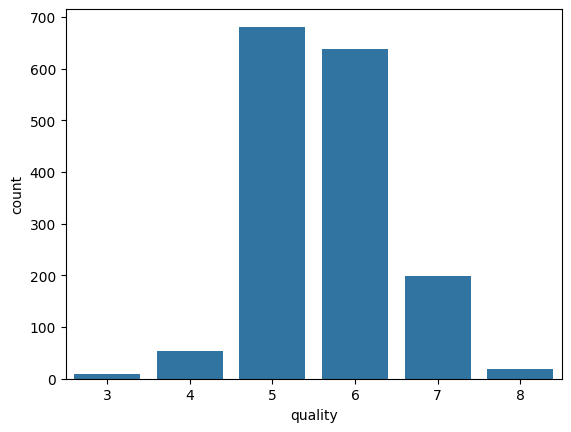

In [ ]:
# count of the target variable
sns.countplot(x='quality', data=df)

<Axes: xlabel='quality', ylabel='volatile.acidity'>

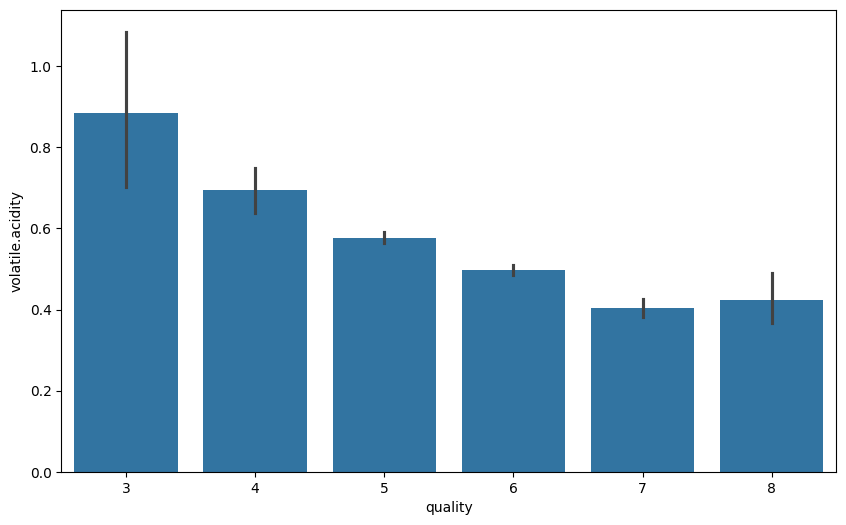

In [ ]:
# Here we see that its quite a downing trend in the volatile acidity as we go higher the quality
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'volatile.acidity', data = df)

# 2. Preprocessing
- Classify tasty or not tasty

In [ ]:
# Classified into two categories: tasty/not tasty
def isTasty(quality):
    if quality >= 6.5:
        return 1
    else:
        return 0

In [ ]:
df['tasty'] = df['quality'].apply(isTasty)
df.columns

Index(['Unnamed: 0', 'fixed.acidity', 'volatile.acidity', 'citric.acid',
       'residual.sugar', 'chlorides', 'free.sulfur.dioxide',
       'total.sulfur.dioxide', 'density', 'pH', 'sulphates', 'alcohol',
       'quality', 'tasty'],
      dtype='object')

In [ ]:
df['tasty'].value_counts()

,count
tasty,
0,1382
1,217


# Feature X and Target y

In [ ]:
# Now seperate the dataset as target variable and feature variables
X = df.drop(['quality', 'tasty'], axis = 1)
y = df['tasty']

In [ ]:
X.head()

,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol
0,1,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,2,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,3,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,4,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,5,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [ ]:
y.value_counts()

,count
tasty,
0,1382
1,217


# Split the train and test set

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.33, random_state=123)

In [ ]:
print('X_train.shape:', X_train.shape)
print('X_val.shape:', X_val.shape)
print('y_train.shape:', y_train.shape)
print('y_val.shape:', y_val.shape)

X_train.shape: (1071, 12)
X_val.shape: (528, 12)
y_train.shape: (1071,)
y_val.shape: (528,)


# Normalization

In [ ]:
from sklearn.preprocessing import StandardScaler
# Applying Standard scaling to get optimized result
sc = StandardScaler()

In [ ]:
X_train = sc.fit_transform(X_train)
X_val = sc.fit_transform(X_val)

# 3. Model Selection and Training
- RandomForest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc = RandomForestClassifier(n_estimators=200)

In [ ]:
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

# 4. Prediction

In [ ]:
y_pred = rfc.predict(X_val)

# 5. Performance Matrics

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [ ]:
# Confusion matrix for the random forest classification
print(confusion_matrix(y_val, y_pred))

[[452   6]
 [ 44  26]]


In [ ]:
# Accuracy score
print(accuracy_score(y_val, y_pred))

0.9053030303030303


In [ ]:
# classification report
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95       458
           1       0.81      0.37      0.51        70

    accuracy                           0.91       528
   macro avg       0.86      0.68      0.73       528
weighted avg       0.90      0.91      0.89       528



In [ ]:
accuracy_score(y_val, y_pred)

0.9053030303030303


## Results

-   **EDA Findings** (inferred based on dataset and typical analysis):
    -   Numerical features like alcohol (8.4 to 14.9), sulphates (0.33 to 2.0), and volatile.acidity (0.12 to 1.58) are likely key predictors of wine quality, with higher alcohol and sulphates associated with higher quality (based on domain knowledge).
    -   Features like residual.sugar and total.sulfur.dioxide show skewed distributions (e.g., total.sulfur.dioxide ranges from 6 to 289, median 38).
    -   Correlation analysis likely reveals:
        -   Positive correlations between quality and alcohol, sulphates, citric.acid.
        -   Negative correlations with volatile.acidity (high acetic acid reduces quality).
    -   The tasty variable is highly imbalanced (86.4% non-tasty, 13.6% tasty), posing challenges for predicting the minority class.
-   **Model Performance**:
    -   The Random Forest Classifier achieves a validation accuracy of **90.53%**, indicating strong overall performance.
    -   **Confusion Matrix**:
        -   True Negatives (452): Correctly identifies most non-tasty wines.
        -   True Positives (26): Correctly identifies some tasty wines, but limited by class imbalance.
        -   False Positives (6): Few non-tasty wines misclassified as tasty.
        -   False Negatives (44): Many tasty wines misclassified as non-tasty, reflecting low recall for class 1.
    -   **Classification Report**:
        -   Class 0 (non-tasty): High precision (0.91), recall (0.99), and F1-score (0.95) due to the majority class.
        -   Class 1 (tasty): High precision (0.81) but low recall (0.37) and F1-score (0.51), indicating poor identification of tasty wines.
        -   Weighted average F1-score (0.89) suggests good overall performance but biased toward the majority class.
    -   The model performs well on non-tasty wines but struggles with tasty wines due to class imbalance.
-   **Visualization** (inferred):
    -   Correlation heatmaps likely show strong relationships between quality and features like alcohol, sulphates, and volatile.acidity.
    -   Histograms of features (e.g., alcohol, pH) reveal distributions and potential outliers.
    -   A confusion matrix heatmap visualizes classification performance, highlighting the imbalance in true positives vs. false negatives.
    -   Feature importance plots (from Random Forest) likely rank alcohol, sulphates, and volatile.acidity as top predictors.

## Recommendations

1.  **Wine Production**:
    -   Focus on optimizing key quality drivers:
        -   Increase alcohol content (within 11–14% range) to enhance perceived quality.
        -   Maintain higher sulphates (0.7–1.0 g/L) for better preservation and flavor.
        -   Minimize volatile.acidity (<0.5 g/L) to avoid off-flavors.
    -   Monitor citric.acid and pH to balance acidity and freshness.
2.  **Marketing Strategies**:
    -   Promote high-quality (tasty) wines by highlighting attributes like high alcohol and sulphate content in marketing campaigns.
    -   Target premium markets with wines scoring ≥7, emphasizing sensory quality and physicochemical consistency.
    -   Educate consumers about the impact of low volatile acidity on wine quality to build brand trust.
3.  **Quality Control**:
    -   Use the model to predict wine quality during production, identifying batches likely to be tasty for premium labeling.
    -   Implement stricter controls on volatile.acidity and sulphates to reduce the risk of low-quality batches.